In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax
from flax import nnx
import orbax.checkpoint as ocp

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum
from jaxpm.utils import _initialize_pk
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.nn import MLP, CNN, HybridNet, ResNet3D, ResNetBlock3D
from jaxpm import camels

jax.devices("gpu")

[cuda(id=0)]

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## Loading the snapshots

In [4]:
# i_snapshots=range(1, 33+4, 4)
i_snapshots=[-2,-1]

In [5]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"

train_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_088.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 2/2 [00:21<00:00, 10.75s/it]


In [6]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1"

test_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    # i_snapshots=range(1, 33+4, 4),
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_088.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 2/2 [00:21<00:00, 10.55s/it]


# functions

In [7]:
# vmap over the snapshots
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

def preprocess(snapshot_dict):
    cosmo = snapshot_dict["cosmo"]
    scales = snapshot_dict["scales"]

    gas_pos = snapshot_dict["gas_poss"]
    dm_pos = snapshot_dict["dm_poss"]
    
    gas_Ps = snapshot_dict["gas_Ps"]
    
    # rho (exactly like in PM)
    rho_dm = vcic_paint(jnp.zeros(mesh_shape), dm_pos, None)
    rho_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, cosmo.Omega_b / cosmo.Omega_c)
    rho = rho_dm + rho_gas
    gas_rho = vcic_read(rho, gas_pos)
    
    # fscalar
    kvec = fftk(mesh_shape)
    delta_k = jax.vmap(jnp.fft.rfftn, in_axes=0)(rho)
    fscalar = jax.vmap(jnp.fft.irfftn, in_axes=0)(delta_k * invnabla_kernel(kvec))
    gas_fscalar = vcic_read(fscalar, gas_pos)

    return scales, gas_pos, gas_rho, gas_fscalar, gas_Ps, rho, fscalar
    

In [8]:
def normalized_paint(positions, weights):
    rho_pos = cic_paint(jnp.zeros([mesh_per_dim] * 3), positions)
    pos_rho = cic_read(rho_pos, positions)

    return cic_paint(jnp.zeros(mesh_shape), positions, weights/pos_rho)

def plot_field(field, ax, vlims=None):
    log_sum = jnp.log10(field.sum(axis=0))

    if vlims is None:
        vmin, vmax = log_sum.min(), log_sum.max()
        vlims = (vmin, vmax)
    else:
        vmin, vmax = vlims
    
    return ax.imshow(log_sum, cmap="magma", vmin=vmin, vmax=vmax), vlims, log_sum

In [9]:
def get_train_step(model, optimizer):

    @jax.jit
    def train_step(params, opt_state, x, y):
    
        def loss_fn(params):
            model = nnx.merge(graphdef, params)
            y_pred = model(*x)
            loss = jnp.mean((y - y_pred) ** 2)
            return loss
        
        loss, grads = jax.value_and_grad(loss_fn)(params)
    
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
    
        return params, opt_state, loss

    return train_step


In [10]:
# class MLP(nnx.Module):
#     def __init__(
#         self, 
#         d_in: int, 
#         d_out: int, 
#         d_hidden: int, 
#         n_hidden: int, 
#         rngs: nnx.Rngs, 
#         activation=jax.nn.relu
#     ):
#         self.d_out = d_out
        
#         self.linear_in = nnx.Linear(d_in, d_hidden, rngs=rngs)
#         self.linear_hid = [nnx.Linear(d_hidden, d_hidden, rngs=rngs) for _ in range(n_hidden)]
#         self.linear_out = nnx.Linear(d_hidden, d_out, rngs=rngs)
#         self.activation = activation

#     def __call__(self, x):
#         x = self.activation(self.linear_in(x))
#         for layer in self.linear_hid:
#             x = self.activation(layer(x))
#         x = self.linear_out(x)
#         return x

# class CNN(nnx.Module):
#     def __init__(
#         self,
#         d_in: int,
#         d_hidden: int,
#         d_out: int,
#         num_layers: int,
#         kernel_size: tuple = (3, 3, 3),
#         strides: int = 1,
#         rngs: nnx.Rngs = nnx.Rngs(0),
#         activation=jax.nn.relu
#     ):
#         self.d_out = d_out
        
#         self.conv_in = nnx.Conv(d_in, d_hidden, kernel_size, strides, padding="SAME", rngs=rngs)
#         self.conv_hidden = [nnx.Conv(d_hidden, d_hidden, kernel_size, strides, padding="SAME", rngs=rngs) for _ in range(num_layers)]
#         self.conv_out = nnx.Conv(d_hidden, d_out, kernel_size, strides, padding="SAME", rngs=rngs)
#         self.activation = activation

#     def __call__(self, x):
#         x = self.conv_in(x)
#         x = self.activation(x)
#         x = self.conv_out(x)

#         return x

# class HybridNet(nnx.Module):
#     def __init__(
#         self, 
#         mlp,
#         cnn,
#         d_out,
#         rngs,
#     ):
#         self.mlp = mlp
#         self.cnn = cnn
#         self.linear_out = nnx.Linear(self.mlp.d_out + self.cnn.d_out, d_out, rngs=rngs)

#         # TODO make case distinction for no batch axis
#         self.vcic_read = jax.vmap(
#             jax.vmap(
#                 cic_read,
#                 # batch dimension
#                 in_axes=(-1, None),
#                 out_axes=-1,
#             ),
#             # scale dimension
#             in_axes=(0, 0),
#         )

#     def __call__(self, pos, particle, field):
#         particle = self.mlp(particle)

#         field = self.cnn(field)
#         field = self.vcic_read(field, pos)

#         x = jnp.concatenate([particle, field], axis=-1)
#         x = self.linear_out(x)

#         return x


In [11]:
def get_data(snapshot_dict):
    scales, gas_pos, gas_rho, gas_fscalar, gas_Ps, rho, fscalar = preprocess(snapshot_dict)
    
    X_particle = jnp.stack(
        [
            jnp.tile(scales, (parts_per_dim**3, 1)).T, 
            np.log10(gas_rho + 1),
            np.arcsinh(gas_fscalar/100)
        ], 
        axis=-1
    )
    X_field = jnp.stack([jnp.log10(rho + 1), jnp.arcsinh(fscalar/100)], axis=-1)
    
    Y = jnp.stack([jnp.log10(gas_Ps + 1)], axis=-1)

    return X_particle, X_field, Y

In [12]:
X_particle, X_field, Y = get_data(train_dict)

mlp = MLP(
    d_in=X_particle.shape[-1], 
    d_out=8, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)

cnn = CNN(
    d_in=X_field.shape[-1], 
    d_out=8,
    d_hidden=16,
    num_layers=1,
    kernel_size=(3, 3, 3),
    strides=1,
    rngs=nnx.Rngs(0)
)

model = HybridNet(
    mlp,
    cnn,
    d_out=1,
    rngs=nnx.Rngs(0),
    batch_axis=True,
)

In [13]:
total_steps = 3_000
batch_size = 1_024
learning_rate = 1e-3
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-3, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
clip_norm = 1

optimizer = optax.chain(
    optax.clip_by_global_norm(clip_norm),
    optax.adam(learning_rate)
)
losses = []

graphdef, params = nnx.split(model)
opt_state = optimizer.init(params)

train_step = get_train_step(model, optimizer)

### training

In [14]:
gas_pos = train_dict["gas_poss"]

100%|██████████| 3000/3000 [01:42<00:00, 29.36it/s]


[None]

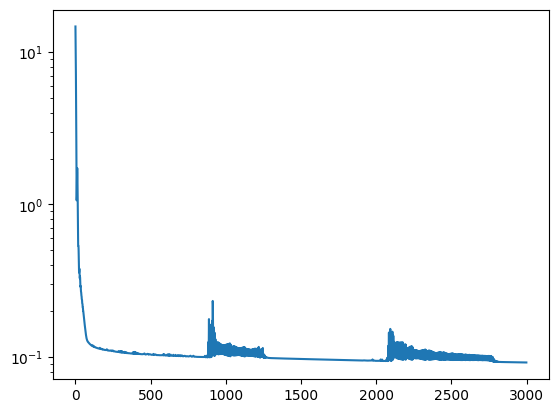

In [15]:
for i in tqdm.tqdm(range(total_steps)):
    # TODO split time steps into batches?
    x = (gas_pos, X_particle, X_field)
    y = Y
    
    params, opt_state, loss = train_step(params, opt_state, x, y)
    losses.append(loss)

model = nnx.merge(graphdef, params)

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

# testing

In [16]:
def plot_comparison(true_field, pred_field, true_label="CAMELS", pred_label="", quantity_label="P", suptitle=""):
    fig, ax = plt.subplots(figsize=(3*6, 6+1), ncols=3)
    
    im, vlims, true_field_log_sum = plot_field(true_field, ax[0])
    ax[0].set(title=true_label)
    
    im, _, pred_field_log_sum = plot_field(pred_field, ax[1], vlims=vlims)
    ax[1].set(title=pred_label)
    
    fig.colorbar(im, ax=ax[:2], label=f"log(sum({quantity_label}))", orientation="horizontal", shrink=0.6, aspect=20)
        
    residual = true_field_log_sum - pred_field_log_sum
    lim = np.max(np.abs(residual[np.isfinite(residual)]))
    im = ax[2].imshow(residual, cmap="seismic", vmin=-lim, vmax=lim)
    ax[2].set(title="residual (true - pred)")
    fig.colorbar(im, ax=ax[2], label=f"log(sum({quantity_label}_1)) - log(sum({quantity_label}_2))", orientation="horizontal", shrink=0.6, aspect=10)
    
    for i in range(len(ax)):
        ax[i].set_yticks([])
        ax[i].set_xticks([])
    
    fig.suptitle(suptitle, fontsize=16)

i_scale = 1

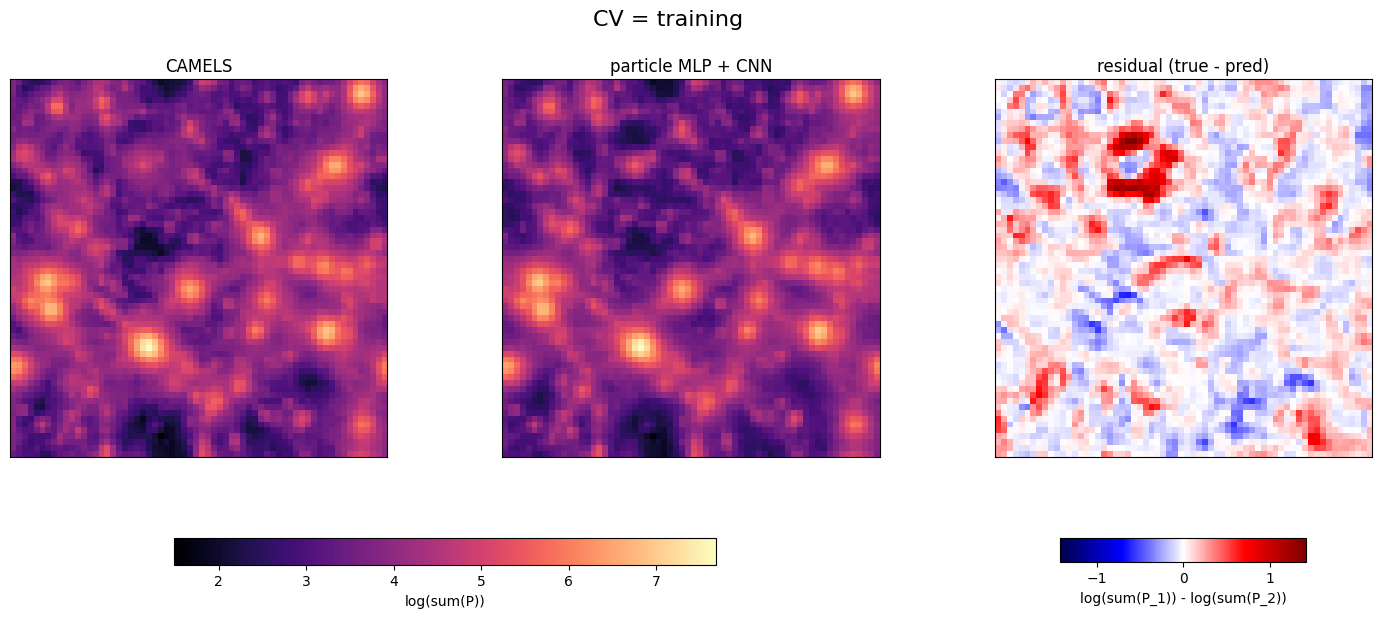

In [17]:
snapshot_dict = train_dict
suptitle = "CV = training"

X_particle_test, X_field_test, Y_test = get_data(snapshot_dict)

gas_P_test = jnp.squeeze(10**model(snapshot_dict["gas_poss"], X_particle_test, X_field_test))
gas_P_test = gas_P_test[i_scale]
P_test = normalized_paint(snapshot_dict["gas_poss"][i_scale], gas_P_test)

P_camels = normalized_paint(snapshot_dict["gas_poss"][i_scale], snapshot_dict["gas_Ps"][i_scale])

plot_comparison(P_camels, P_test, pred_label="particle MLP + CNN", suptitle=suptitle)

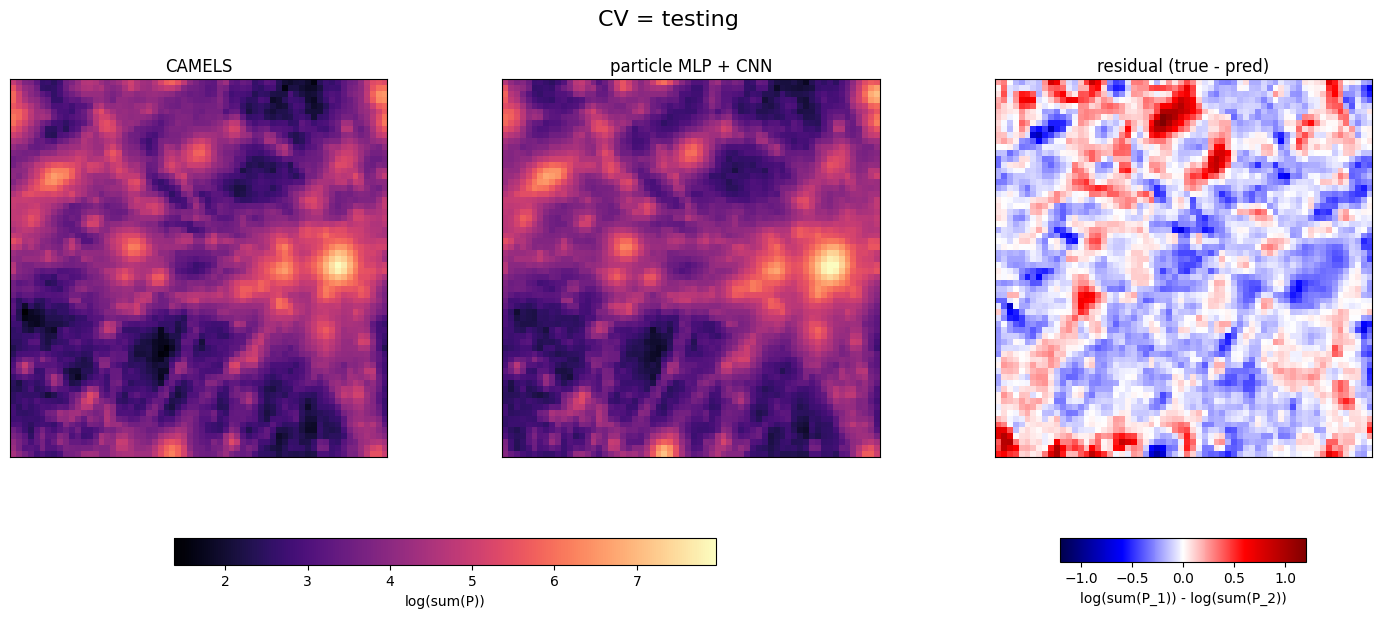

In [18]:
snapshot_dict = test_dict
suptitle = "CV = testing"

X_particle_test, X_field_test, Y_test = get_data(snapshot_dict)

gas_P_test = jnp.squeeze(10**model(snapshot_dict["gas_poss"], X_particle_test, X_field_test))
gas_P_test = gas_P_test[i_scale]
P_test = normalized_paint(snapshot_dict["gas_poss"][i_scale], gas_P_test)

P_camels = normalized_paint(snapshot_dict["gas_poss"][i_scale], snapshot_dict["gas_Ps"][i_scale])

plot_comparison(P_camels, P_test, pred_label="particle MLP + CNN", suptitle=suptitle)

# trash